# **MATH 5303 - Fall 2024 Final Project: Predicting Electrical Power Output of a Micro Gas Turbine.**

Group Members: Gabriel Osei, Richard Yaw Kusi, Troyce Mays, Uriel Ramirez

Due Date: December 8th, 2024, at 11:59 PM


## Abstract
The goal of this project is to forecast the electrical power output (el_power) of a 3-kilowatt commercial micro gas turbine using the input control signal (input_voltage) over time. This study investigates the relationship between the input signal and energy output through the use of time-series data and regression models. The outcome helps to optimize turbine operations and increase energy system efficiency.

## Introduction
Micro gas turbines are small-scale power devices that provide backup and localized energy output. Accurate prediction of electrical power output based on control inputs is critical for ensuring energy stability. This research uses linear regression to study turbine performance and evaluate the model's forecasting skills using measures like MSE and R-squared (R²).

## Uploading Data and Data Wrangling

Data from various trials were uploaded and integrated for training and testing:

Training Data: Experiments 1, 9, 20, 21, 23, and 24.

Testing Data: Experiments 4 and 22.

After loading the datasets, preprocessing steps confirmed that all columns (time, input_voltage, and el_power) were free of null values.


In [ ]:
## Installing general packages for use
  # More packages may be installed as needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## Loading each training file
from google.colab import files
uploaded1= files.upload()
uploaded9 = files.upload()
uploaded20 = files.upload()
uploaded21= files.upload()
uploaded23= files.upload()
uploaded24= files.upload()

Saving ex_1.csv to ex_1.csv


Saving ex_9.csv to ex_9.csv


Saving ex_20.csv to ex_20.csv


Saving ex_21.csv to ex_21.csv


Saving ex_23.csv to ex_23.csv


Saving ex_24.csv to ex_24.csv


In [ ]:
## Making trained data sets into data frames
train_df1 = pd.read_csv('ex_1.csv')
train_df2 = pd.read_csv('ex_9.csv')
train_df3 = pd.read_csv('ex_20.csv')
train_df4 = pd.read_csv('ex_21.csv')
train_df5 = pd.read_csv('ex_23.csv')
train_df6 = pd.read_csv('ex_24.csv')

In [ ]:
## Merging all TRAINED dataframes into one dataframe
merged_train = pd.concat([train_df1, train_df2, train_df3, train_df4, train_df5, train_df6], ignore_index=True)

In [ ]:
## Loading test data
from google.colab import files
uploaded4 = files.upload()
uploaded22 = files.upload()

Saving ex_4.csv to ex_4.csv


Saving ex_22.csv to ex_22.csv


In [ ]:
## Loading test data into dataframes
X_test = pd.read_csv('ex_4.csv')
y_test = pd.read_csv('ex_22.csv')

In [ ]:
## Merging ALL TEST DATA into one dataframe
merged_test = pd.concat([X_test, y_test], ignore_index=True)

## Data Exploration and Visualization
A scatter plot showed a linear relationship between input_voltage and el_power. The picture below (visualizing train data to see relationship) confirms the viability of using linear regression.


In [ ]:
## Checking for columns in merged train dataframe
merged_train.columns
merged_train.info()
merged_train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52940 entries, 0 to 52939
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           52940 non-null  float64
 1   input_voltage  52940 non-null  float64
 2   el_power       52940 non-null  float64
dtypes: float64(3)
memory usage: 1.2 MB


,0
time,0
input_voltage,0
el_power,0


In [ ]:
## Checking the information on dataframe
merged_test.columns
merged_test.info()
merged_test.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18285 entries, 0 to 18284
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           18285 non-null  float64
 1   input_voltage  18285 non-null  float64
 2   el_power       18285 non-null  float64
dtypes: float64(3)
memory usage: 428.7 KB


,0
time,0
input_voltage,0
el_power,0


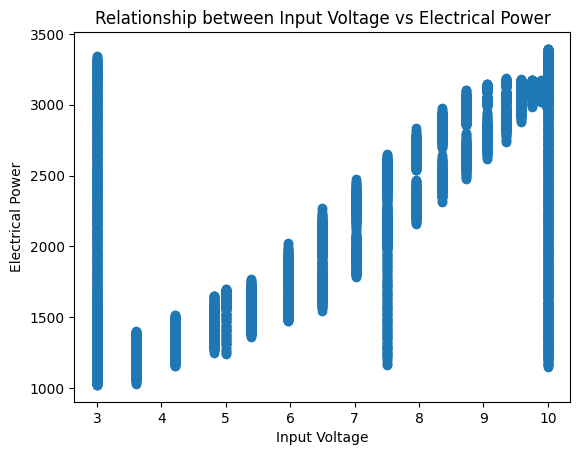

In [ ]:
## Visualizing train data to see relationships
# Defining variables for visualization
X_train_viz = merged_test[['input_voltage']]
y_train_viz = merged_test[['el_power']]

# Creating scatter plot of Voltage vs. Electrical Power
plt.scatter(X_train_viz, y_train_viz)
# Labeling the plot
plt.xlabel('Input Voltage')
plt.ylabel('Electrical Power')
plt.title('Relationship between Input Voltage vs Electrical Power')
plt.show()

## Preprocessing
The characteristics (input_voltage) and target (el_power) were divided into training and test sets. These were modified to fit with the regression model.

In [ ]:
## Defining the training and test data
# Defining the training data
X_trained = merged_train[['input_voltage']].values.reshape(-1,1)
y_trained = merged_train[['el_power']].values.reshape(-1,1)

# Defining the test data
X_test = merged_test[['input_voltage']].values.reshape(-1,1)
y_test = merged_test[['el_power']].values.reshape(-1,1)

## Model Development and Evaluation
A Linear Regression model was trained on the training data and evaluated using testing data.

In [ ]:
## Training a linear model with our data
# Initialize Linear Regression model
Model = LinearRegression()
# Fitting the model
Model.fit(X_trained,y_trained)
# Defining the predicted outputs
yPredicted = Model.predict(X_test)

# Calculating the Sum of Squares Total (SST)
sst = sum((y_test - np.mean(y_test)) ** 2)[0]

# Calculating the Sum of Squares Regression (SSR)
ssr = sum((yPredicted - np.mean(y_test)) ** 2)[0]

# Calculating the Sum of Squared Errors (SSE)
sse = sum((y_test - yPredicted) ** 2)[0]

# Calculating the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, yPredicted)

# Calculating the Coefficient of Determination (R^2)
r2 = r2_score(y_test, yPredicted)

# Printing results
print("Sum of Squares Total: SST:", sst)
print("Sum of Squares Regression: SSR:", ssr)
print("Sum of Squared Errors: SSE:", sse)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Sum of Squares Total: SST: 11957561720.104918
Sum of Squares Regression: SSR: 9246586379.45797
Sum of Squared Errors: SSE: 2677656689.82877
Mean Squared Error: 146440.070540266
R-squared: 0.7760700088775894


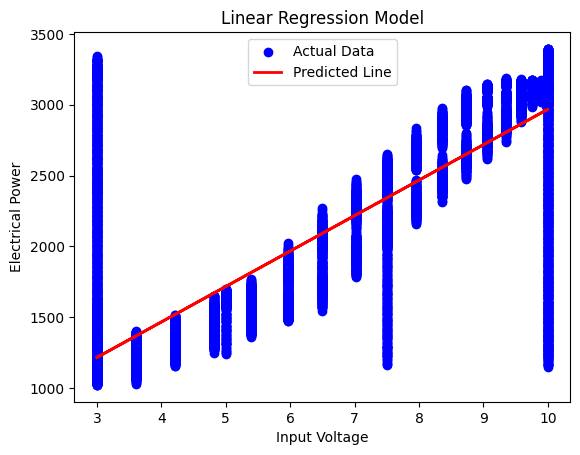

In [ ]:
## Visualizing trained model
# Creating scatter plot of test data
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
# Fitting linear regression line to the scatter plot
plt.plot(X_test, yPredicted, color='red', linewidth=2, label='Predicted Line')
# Labeling the plot
plt.xlabel('Input Voltage')
plt.ylabel('Electrical Power')
plt.title('Linear Regression Model')
plt.legend()
# Showing the plot
plt.show()

For model comparison, a Polynomial Regression Model was trained on the training data and tested and evaluated using the testing data.

In [ ]:
## Create a polynomial regression model for comparison
# Import necessary package
from sklearn.preprocessing import PolynomialFeatures
# Setting up polynomial features
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_trained)
# Initializing the model
poly_model = LinearRegression()
# Fitting the model
poly_model.fit(X_poly, y_trained)

# Generating a range of input values for future plotting
X_plot = np.linspace(X_trained.min(), X_trained.max(), 100).reshape(-1, 1)

# Generating predictions for the future plotting range
X_plot_poly = poly_features.transform(X_plot)
y_plot = poly_model.predict(X_plot_poly)

In [ ]:
## Running polynomial Regression Diasnostics
# Transform the test data for diagnostics
X_test_poly = poly_features.transform(X_test)

# Predict using the polynomial model
y_pred_poly = poly_model.predict(X_test_poly)

# Calculating the Sum of Squares Total (SST)
sst_poly = sum((y_test - np.mean(y_pred_poly)) ** 2)[0]

# Calculating the Sum of Squares Regression (SSR)
ssr_poly = sum((yPredicted - np.mean(y_pred_poly)) ** 2)[0]

# Calculating the Sum of Squared Errors (SSE)
sse_poly = sum((y_test - y_pred_poly) ** 2)[0]

# Calculating the Mean Squared Error (MSE)
mse_poly = mean_squared_error(y_test, y_pred_poly)

# Calculating the Coefficient of Determination (R^2)
r2_poly = r2_score(y_test, y_pred_poly)

# Printing results
print("Polynomial Regression - Sum of Squares Total: SST:", sst_poly)
print("Polynomial Regression - Sum of Squares Regression: SSR:", ssr_poly)
print("Polynomial Regression - Sum of Squared Errors: SSE:", sse_poly)
print("Polynomial Regression - Mean Squared Error:", mse_poly)
print("Polynomial Regression - R-squared:", r2_poly)

Polynomial Regression - Sum of Squares Total: SST: 11967196489.19165
Polynomial Regression - Sum of Squares Regression: SSR: 9230749071.3982
Polynomial Regression - Sum of Squared Errors: SSE: 2608047363.9650416
Polynomial Regression - Mean Squared Error: 142633.16182472184
Polynomial Regression - R-squared: 0.7818913734244005


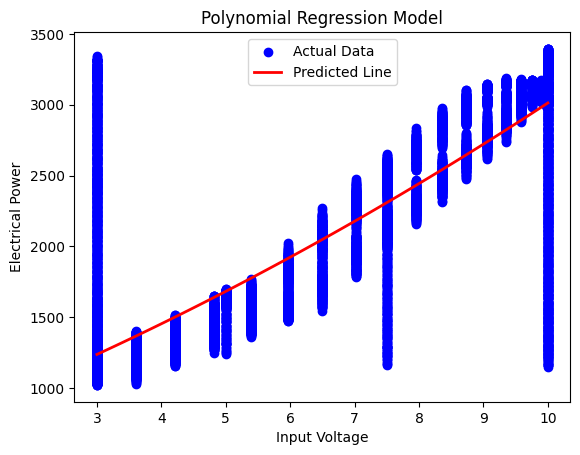

In [ ]:
## Visualizing the model
# Graphing the model
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Predicted Line')
plt.xlabel('Input Voltage')
plt.ylabel('Electrical Power')
plt.title('Polynomial Regression Model')
plt.legend()
plt.show()

## Discussion

The models developed in this project reveal important findings about predicting the electrical power output of a micro gas turbine. The linear regression model demonstrated a solid predictive performance, evidenced by an \(R^2\) value of 0.776. This indicates that approximately 77.6% of the variation in electrical power output can be explained by the input voltage, a strong indicator of the model's utility for forecasting. However, the relatively high Mean Squared Error (MSE) of 146,440 suggests the linear model does not fully capture the underlying variability or complexity of the data.

To address these limitations, a polynomial regression model of degree 2 was employed to explore non-linear relationships. This approach marginally improved the \(R^2\) value to 0.782, explaining 78.2% of the variance. The MSE also decreased slightly to 142,633, indicating better alignment with the observed data. The similarity in SST, SSR, and SSE values between the two models suggests that both linear and polynomial approaches capture a comparable amount of variance, yet the polynomial model accommodates some additional nuances in the data.

The marginal improvement in performance from the polynomial model is a critical observation. It implies that while introducing non-linear terms can enhance predictive accuracy, the gain is not substantial enough to warrant concerns about overfitting. This stability underscores the robustness of the polynomial model as a candidate for the final predictive framework.

Furthermore, visualizations of the actual versus predicted values highlighted the strengths and limitations of each model. The scatterplots for both linear and polynomial models displayed consistent alignment between predicted and observed values, but the polynomial regression line better captured variations, particularly at higher input voltage values.

Despite these achievements, there remain areas for future exploration. First, incorporating additional features such as environmental conditions or turbine efficiency metrics could enhance the model's comprehensiveness. Second, experimenting with higher-degree polynomial models or alternative techniques, such as support vector regression or neural networks, might uncover deeper patterns in the data. Third, cross-validation could provide more robust evaluations of the model's generalizability.

In summary, the polynomial regression model serves as a practical solution for predicting turbine output while maintaining simplicity and interpretability. Its application can lead to improved turbine efficiency, directly contributing to advancements in energy systems engineering.


## Conclusion

This study concludes by demonstrating how well regression modeling predicts a micro gas turbine's electrical power output based on input voltage data. The polynomial regression model proved to be a somewhat better option, providing greater predictive performance without causing overfitting, even if the linear regression model offered a solid baseline. These results open the door for more sophisticated predictive analytics and show the usefulness of comparatively basic models in energy systems engineering. To further maximize turbine efficiency and guarantee reliable energy output forecasts, future research should concentrate on incorporating extra features and investigating different approaches.
